In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 전처리
df = pd.read_csv('../../../data/processed/steam_indie_games_merged_v1.csv')
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['positive_rate'] = (df['total_positive'] / df['total_reviews']) * 100

In [14]:
df['release_year'].value_counts()

release_year
2024    89
2023    75
2025    34
Name: count, dtype: int64

In [3]:
# Indie 태그 제거 정제
def clean_genres(s):
    try:
        g = ast.literal_eval(s)
        return str([i.strip() for i in g if i.strip() != 'Indie'])
    except: return "Others"
df['genre_clean'] = df['genres'].apply(clean_genres)

# 필터링 1: 리뷰 30개 이상
df_f = df[df['total_reviews'] >= 30].copy()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final.nlargest(5, 'med_rev'), x='med_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 0], palette='viridis')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final.nlargest(5, 'med_pos'), x='med_pos', y=final.nlargest(5, 'med_pos').index, ax=axes[i, 1], palette='magma')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable

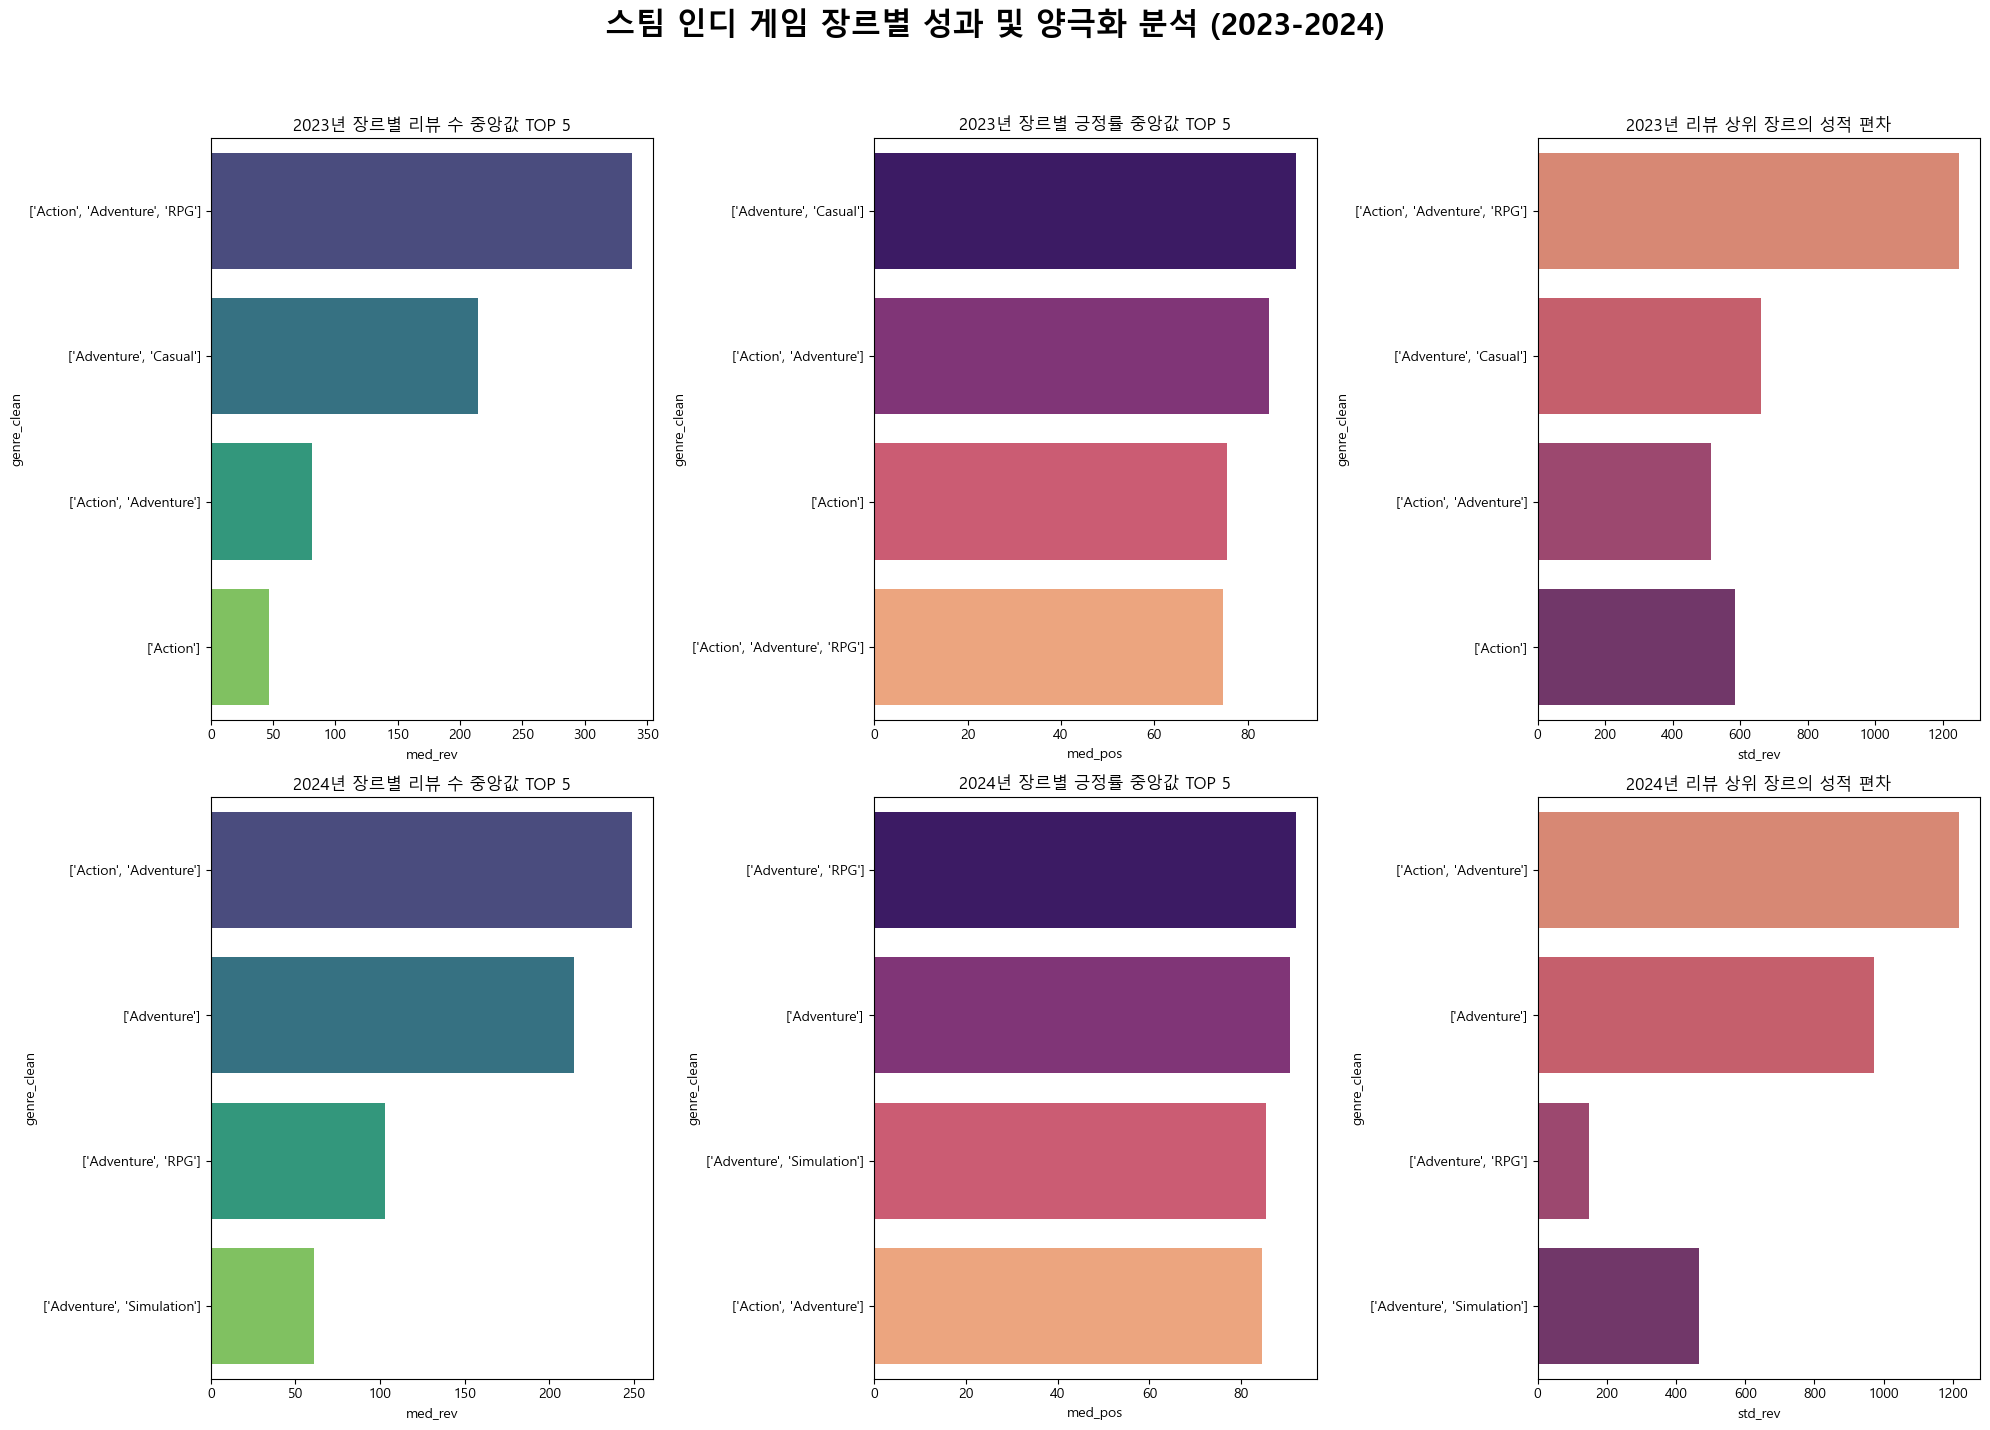

In [10]:
# 시각화 설정 (2023, 2024년)
years = [2023, 2024]
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

for i, y in enumerate(years):
    y_df = df_f[df_f['release_year'] == y]
    # 필터링 2: 게임 3개 이상 장르
    stats = y_df.groupby('genre_clean').agg({'total_reviews':['median','std','count'], 'positive_rate':'median'})
    stats.columns = ['med_rev', 'std_rev', 'count', 'med_pos']
    final = stats[stats['count'] >= 3]
    
    # 그래프 1: 리뷰 중앙값 Top 5
    sns.barplot(data=final.nlargest(5, 'med_rev'), x='med_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 0], palette='viridis')
    axes[i, 0].set_title(f'{y}년 장르별 리뷰 수 중앙값 TOP 5')
    
    # 그래프 2: 긍정률 중앙값 Top 5
    sns.barplot(data=final.nlargest(5, 'med_pos'), x='med_pos', y=final.nlargest(5, 'med_pos').index, ax=axes[i, 1], palette='magma')
    axes[i, 1].set_title(f'{y}년 장르별 긍정률 중앙값 TOP 5')
    
    # 그래프 3: 상위 리뷰 장르의 표준편차
    sns.barplot(data=final.nlargest(5, 'med_rev'), x='std_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 2], palette='flare')
    axes[i, 2].set_title(f'{y}년 리뷰 상위 장르의 성적 편차')

plt.suptitle('스팀 인디 게임 장르별 성과 및 양극화 분석 (2023-2024)', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 메인 제목과 그래프가 겹치지 않게 여백 조절
plt.show()

In [11]:
# Indie 태그 제거 정제
def clean_genres(s):
    try:
        g = ast.literal_eval(s)
        return str([i.strip() for i in g if i.strip() != 'Indie'])
    except: return "Others"
df['genre_clean'] = df['genres'].apply(clean_genres)

# 필터링 1: 리뷰 20개 이상
df_f = df[df['total_reviews'] >= 20].copy()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final.nlargest(5, 'med_rev'), x='med_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 0], palette='viridis')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final.nlargest(5, 'med_pos'), x='med_pos', y=final.nlargest(5, 'med_pos').index, ax=axes[i, 1], palette='magma')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33256\3979813048.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable

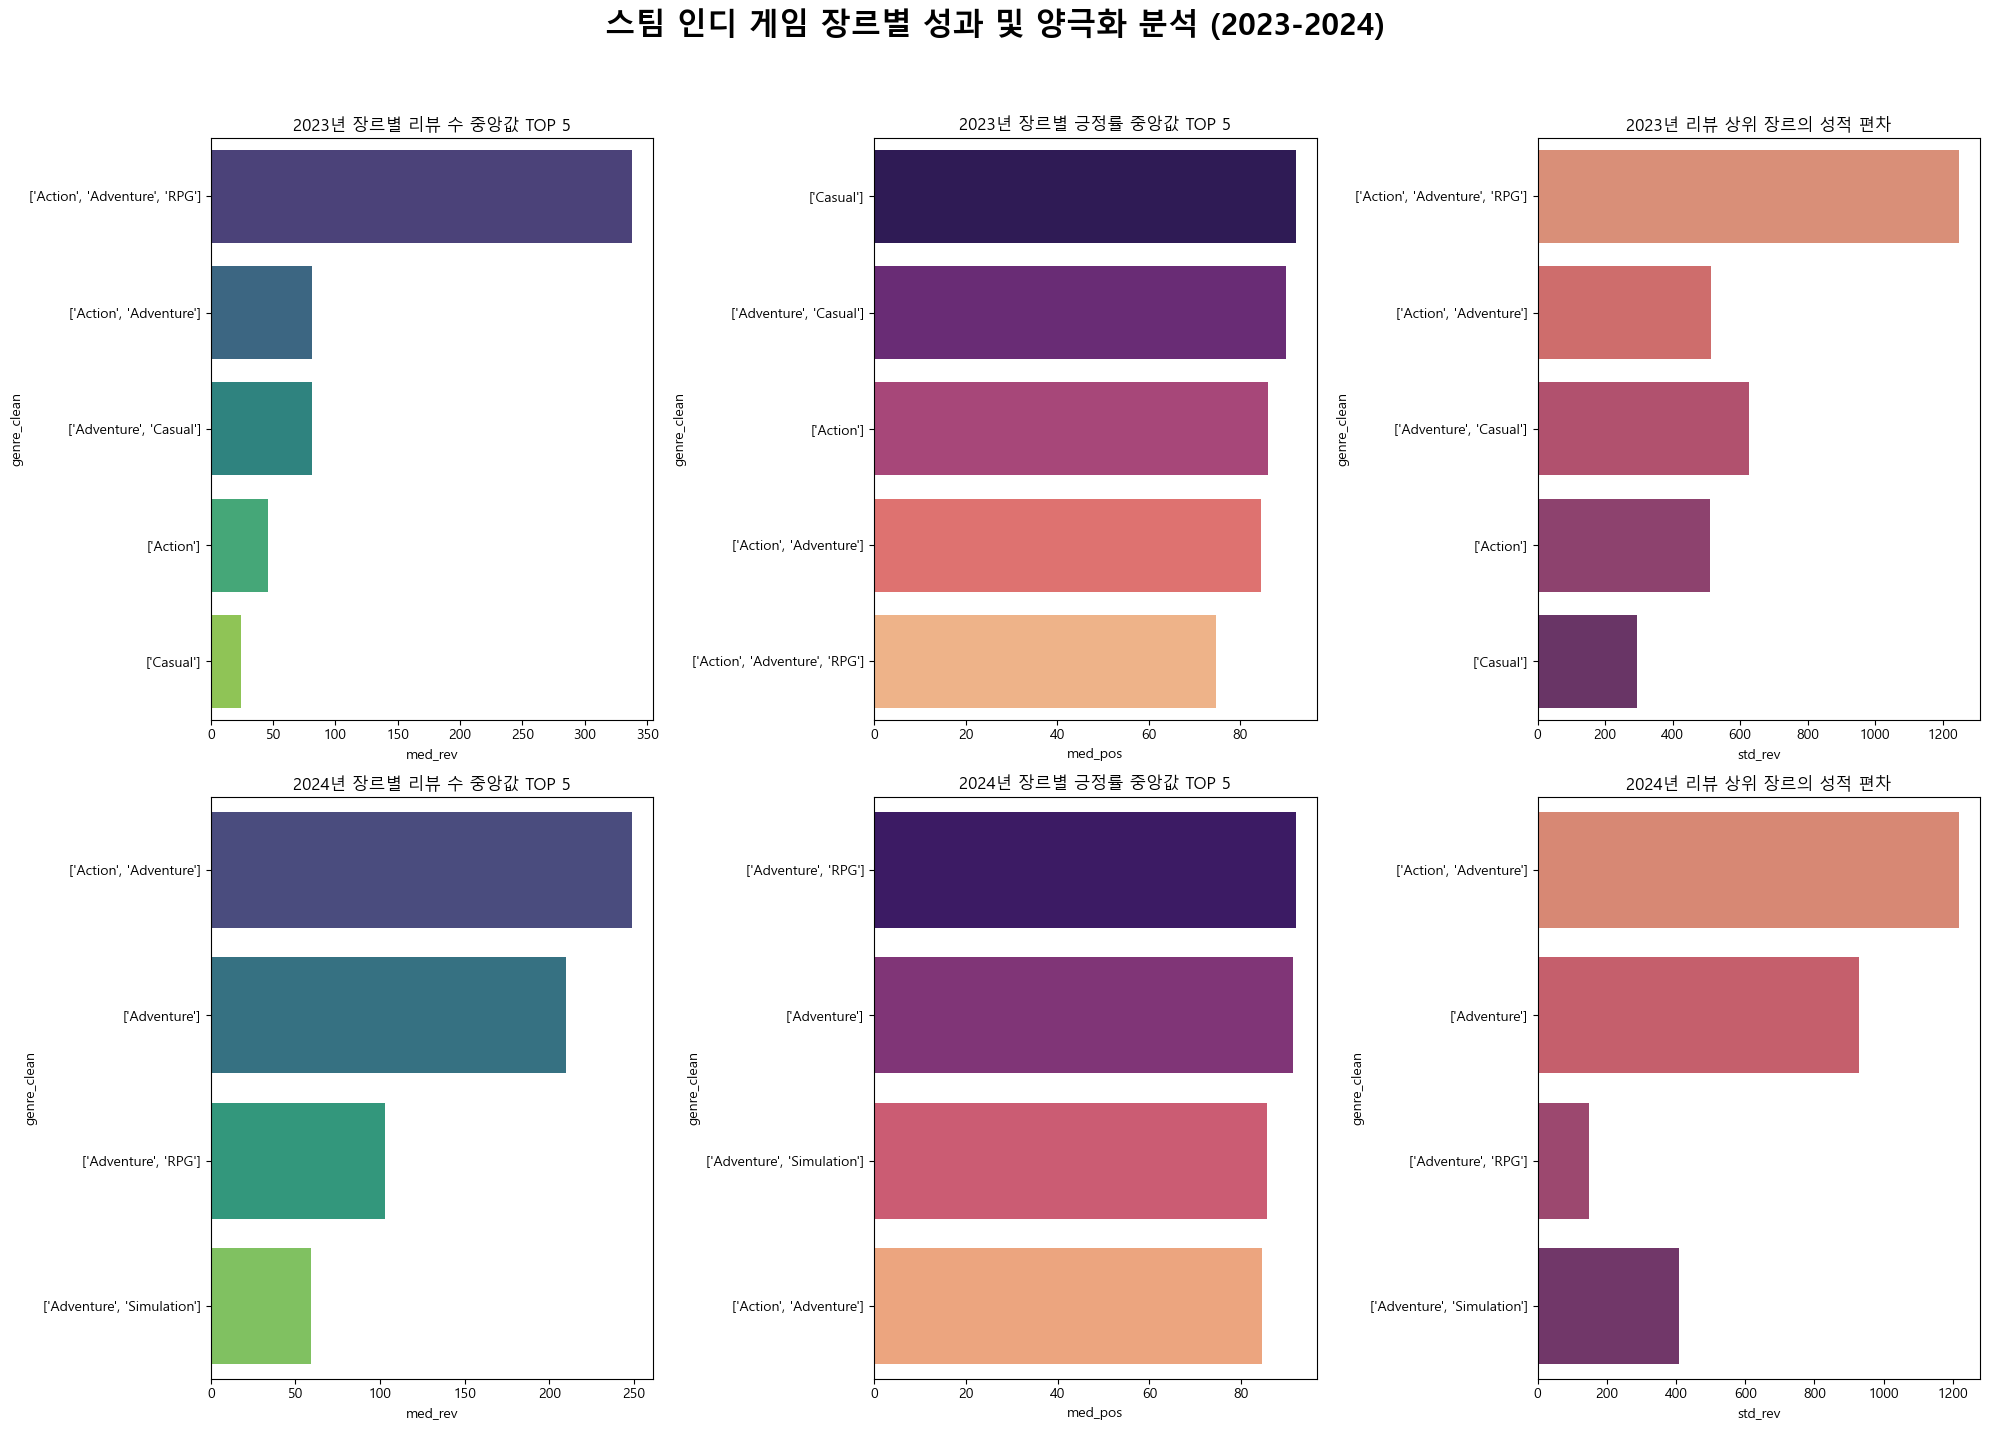

In [13]:
# 시각화 설정 (2023, 2024년)
years = [2023, 2024]
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

for i, y in enumerate(years):
    y_df = df_f[df_f['release_year'] == y]
    # 필터링 2: 게임 3개 이상 장르
    stats = y_df.groupby('genre_clean').agg({'total_reviews':['median','std','count'], 'positive_rate':'median'})
    stats.columns = ['med_rev', 'std_rev', 'count', 'med_pos']
    final = stats[stats['count'] >= 3]
    
    # 그래프 1: 리뷰 중앙값 Top 5
    sns.barplot(data=final.nlargest(5, 'med_rev'), x='med_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 0], palette='viridis')
    axes[i, 0].set_title(f'{y}년 장르별 리뷰 수 중앙값 TOP 5')
    
    # 그래프 2: 긍정률 중앙값 Top 5
    sns.barplot(data=final.nlargest(5, 'med_pos'), x='med_pos', y=final.nlargest(5, 'med_pos').index, ax=axes[i, 1], palette='magma')
    axes[i, 1].set_title(f'{y}년 장르별 긍정률 중앙값 TOP 5')
    
    # 그래프 3: 상위 리뷰 장르의 표준편차
    sns.barplot(data=final.nlargest(5, 'med_rev'), x='std_rev', y=final.nlargest(5, 'med_rev').index, ax=axes[i, 2], palette='flare')
    axes[i, 2].set_title(f'{y}년 리뷰 상위 장르의 성적 편차')

plt.suptitle('스팀 인디 게임 장르별 성과 및 양극화 분석 (2023-2024)', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 메인 제목과 그래프가 겹치지 않게 여백 조절
plt.show()